### Setup

In [1]:
!./venv/bin/pip install kaggle scikit-learn numpy matplotlib seaborn

  Using cached kaggle-2.0.0-py3-none-any.whl.metadata (15 kB)
  Using cached scikit_learn-1.8.0-cp313-cp313-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached numpy-2.4.2-cp313-cp313-macosx_11_0_arm64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.10.8-cp313-cp313-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached bleach-6.3.0-py3-none-any.whl.metadata (31 kB)
  Using cached kagglesdk-0.1.15-py3-none-any.whl.metadata (13 kB)
  Using cached protobuf-6.33.5-cp39-abi3-macosx_10_9_universal2.whl.metadata (593 bytes)
  Using cached python_slugify-8.0.4-py2.py3-none-any.whl.metadata (8.5 kB)
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached urllib3-2.6.3-py3-none-any.whl.metadata (6.9 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using ca

In [2]:
!kaggle datasets download --unzip -d abcsds/pokemon

Dataset URL: https://www.kaggle.com/datasets/abcsds/pokemon
License(s): CC0-1.0
100%|██████████████████████████████████████| 14.9k/14.9k [00:00<00:00, 13.8MB/s]



### Imports

In [259]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.covariance import EllipticEnvelope
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, ConfusionMatrixDisplay, classification_report, roc_curve, roc_auc_score

### Load Dataset

In [4]:
df = pd.read_csv("Pokemon.csv")

In [5]:
df.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


In [6]:
df.describe()

,#,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation
count,800.000000,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.00000
mean,362.813750,435.10250,69.258750,79.001250,73.842500,72.820000,71.902500,68.277500,3.32375
std,208.343798,119.96304,25.534669,32.457366,31.183501,32.722294,27.828916,29.060474,1.66129
min,1.000000,180.00000,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000,1.00000
25%,184.750000,330.00000,50.000000,55.000000,50.000000,49.750000,50.000000,45.000000,2.00000
50%,364.500000,450.00000,65.000000,75.000000,70.000000,65.000000,70.000000,65.000000,3.00000
75%,539.250000,515.00000,80.000000,100.000000,90.000000,95.000000,90.000000,90.000000,5.00000
max,721.000000,780.00000,255.000000,190.000000,230.000000,194.000000,230.000000,180.000000,6.00000


### Choosing Two Columns

First, I want to know the value counts for columns of type string.

We can see that name is a unique value, even though the name can be composite (e.g. Venusaur and VenusaurMega Venusaur), I doubt it is worth trying to encode it. Type 1 and Type 2 columns also have a high diversity in values, so they are also candidates to be dropped.

In [13]:
str_cols = ['Name', 'Type 1', 'Type 2']
for col in str_cols:
    print(df[col].value_counts())

Name
Bulbasaur                1
Ivysaur                  1
Venusaur                 1
VenusaurMega Venusaur    1
Charmander               1
                        ..
Diancie                  1
DiancieMega Diancie      1
HoopaHoopa Confined      1
HoopaHoopa Unbound       1
Volcanion                1
Name: count, Length: 800, dtype: int64
Type 1
Water       112
Normal       98
Grass        70
Bug          69
Psychic      57
Fire         52
Electric     44
Rock         44
Ground       32
Ghost        32
Dragon       32
Dark         31
Poison       28
Fighting     27
Steel        27
Ice          24
Fairy        17
Flying        4
Name: count, dtype: int64
Type 2
Flying      97
Ground      35
Poison      34
Psychic     33
Fighting    26
Grass       25
Fairy       23
Steel       22
Dark        20
Dragon      18
Ice         14
Rock        14
Water       14
Ghost       14
Fire        12
Electric     6
Normal       4
Bug          3
Name: count, dtype: int64


Type 2 also has many missing values

In [7]:
df.isna().sum()

#               0
Name            0
Type 1          0
Type 2        386
Total           0
HP              0
Attack          0
Defense         0
Sp. Atk         0
Sp. Def         0
Speed           0
Generation      0
Legendary       0
dtype: int64

In [26]:
clean_df = df.drop(columns=str_cols)

Drop index column

In [28]:
clean_df.drop(clean_df.columns[0], axis=1, inplace=True)

Let's convert Legendary to 0/1 values to create a correlation heatmap

In [16]:
clean_df['Legendary'] = clean_df['Legendary'].replace({True: 1, False: 0})

In [29]:
clean_df.head()

,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,318,45,49,49,65,65,45,1,False
1,405,60,62,63,80,80,60,1,False
2,525,80,82,83,100,100,80,1,False
3,625,80,100,123,122,120,80,1,False
4,309,39,52,43,60,50,65,1,False


<Axes: >

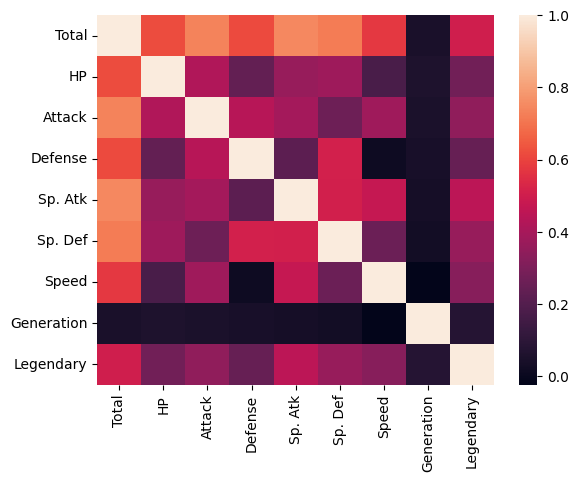

In [30]:
corr = clean_df.corr()
sns.heatmap(corr)

`Total` and `Sp. Atk` seem to have the most correlation to `Legendary` (target column), so we are going to use them for outlier detection.

In [22]:
corr['Legendary'].sort_values(ascending=False)

Legendary     1.000000
Total         0.501758
Sp. Atk       0.448907
Sp. Def       0.363937
Attack        0.345408
Speed         0.326715
HP            0.273620
Defense       0.246377
#             0.153396
Generation    0.079794
Name: Legendary, dtype: float64

In [65]:
outlier_df = clean_df[['Total', 'Sp. Atk']]
outlier_df.head()

,Total,Sp. Atk
0,318,65
1,405,80
2,525,100
3,625,122
4,309,60


### Outlier Detection

#### Plot Legendary Entries

Our goal is to predict whether or not a pokemon is legendary. However, a pokemon being legendary is a rare sight, and it is more likely that a legendary pokemon is an outlier.

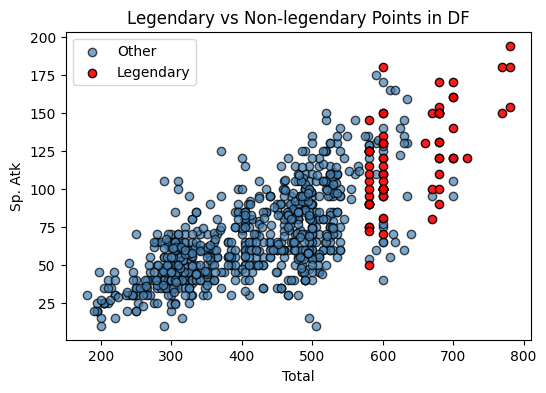

In [233]:
legendary_mask = clean_df["Legendary"] == True

plt.figure(figsize=(6, 4))
plt.scatter(
    clean_df.loc[~legendary_mask, "Total"],
    clean_df.loc[~legendary_mask, "Sp. Atk"],
    c="steelblue", label="Other", alpha=0.7, edgecolors="k"
)
plt.scatter(
    clean_df.loc[legendary_mask, "Total"],
    clean_df.loc[legendary_mask, "Sp. Atk"],
    c="red", label="Legendary", alpha=0.9, edgecolors="k"
)
plt.xlabel("Total")
plt.ylabel("Sp. Atk")
plt.title("Legendary vs Non-legendary Points in DF")
plt.legend()

#### Normalization

Before proceeding with outlier detection, let's normalize the columns. To do that, plot the columns to see which scalind method applies the best

<Axes: ylabel='Density'>

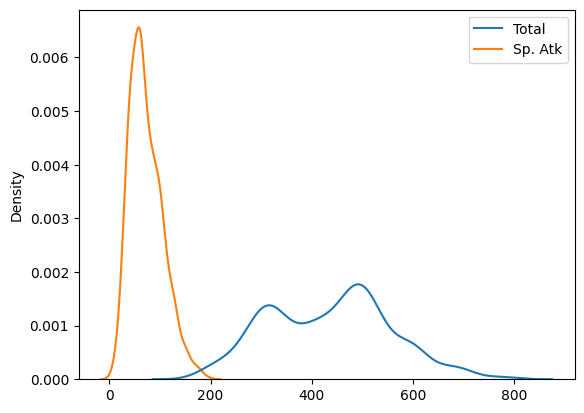

In [41]:
sns.kdeplot(data=outlier_df)

The plots look like a normal distribution, so we can applying `StandardScaler` would be a good choice

#### Box Plot

According to box plot, `Total` column has no outliers, while `Sp. Atk` column has some outliers outside the maximum range of values.

<Axes: >

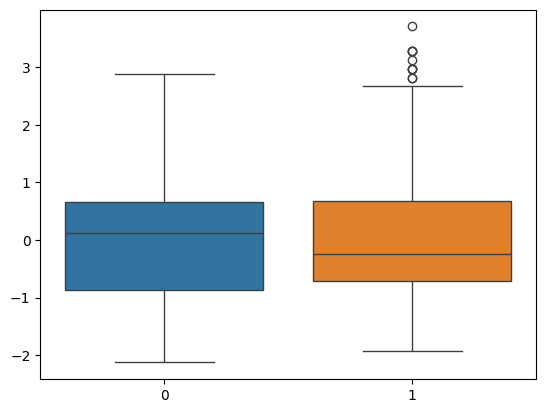

In [47]:
sns.boxplot(data=outlier_df)

#### General Outlier Detection Workflow

In [115]:
def gen_labels(model):
    outlier_scaler = StandardScaler()
    outlier_scaled = outlier_scaler.fit_transform(outlier_df)
    labels = model.fit_predict(outlier_scaled)

    return labels

def create_model(Model, contamination):
    model = Model()

    if hasattr(model, 'contamination'):
        model.contamination = contamination

    if hasattr(model, 'random_state'):
        model.random_state = 42

    return model

def plot_outliers(ax, labels, title):
    colors = np.where(labels == -1, 'red', 'steelblue')

    ax.scatter(x = outlier_df['Total'], y = outlier_df['Sp. Atk'], c=colors, alpha=0.8, edgecolor='k')
    ax.set_xlabel('Total')
    ax.set_ylabel('Sp. Atk')
    ax.set_title(title)

def plot_outlier_rate(model_name, cons, outliers):
    plt.plot(cons, outliers)
    plt.scatter(cons, outliers)
    plt.xlabel('contamination')
    plt.ylabel('# of outliers')
    plt.title(f'{model_name} Contamination vs # of Outliers')
    plt.grid()

#### Plotting Outliers for each Model

Here I will visually evaluate each outlier estimation model.

`IsolationForest` model does a pretty good job at pruning outliers, however for each of the `contamination` values we can see some regions that could have been marked as outliers. For example, for `contamination = 0.1`, the point around `(650, 100)`, or for `contamination = 0.2` the cluster around `(600, 75)`.

`EllipticEnvelope` is visually the most appealing to my eye, because the cluster distribution looks elliptical. Even for a `contamination = 0.2`, the points from main cluster have not been marked as outliers by the model.

`LocalOutlierFactor` did the worst, marking as outliers some points from smaller clusters, even though the entire cluster should have been labeled. For large `contamination` values, the model starts marking the points close to the center of the main cluster, which is not the desired behaviour.


`OneClassSVM` has marked around a half of the dataset as outliers, which is too big of a prune. Since it does not have `contamination` hyperparameter, the auto-tuning did not do a good job fitting the dataset. It has to be tuned using other parameters.

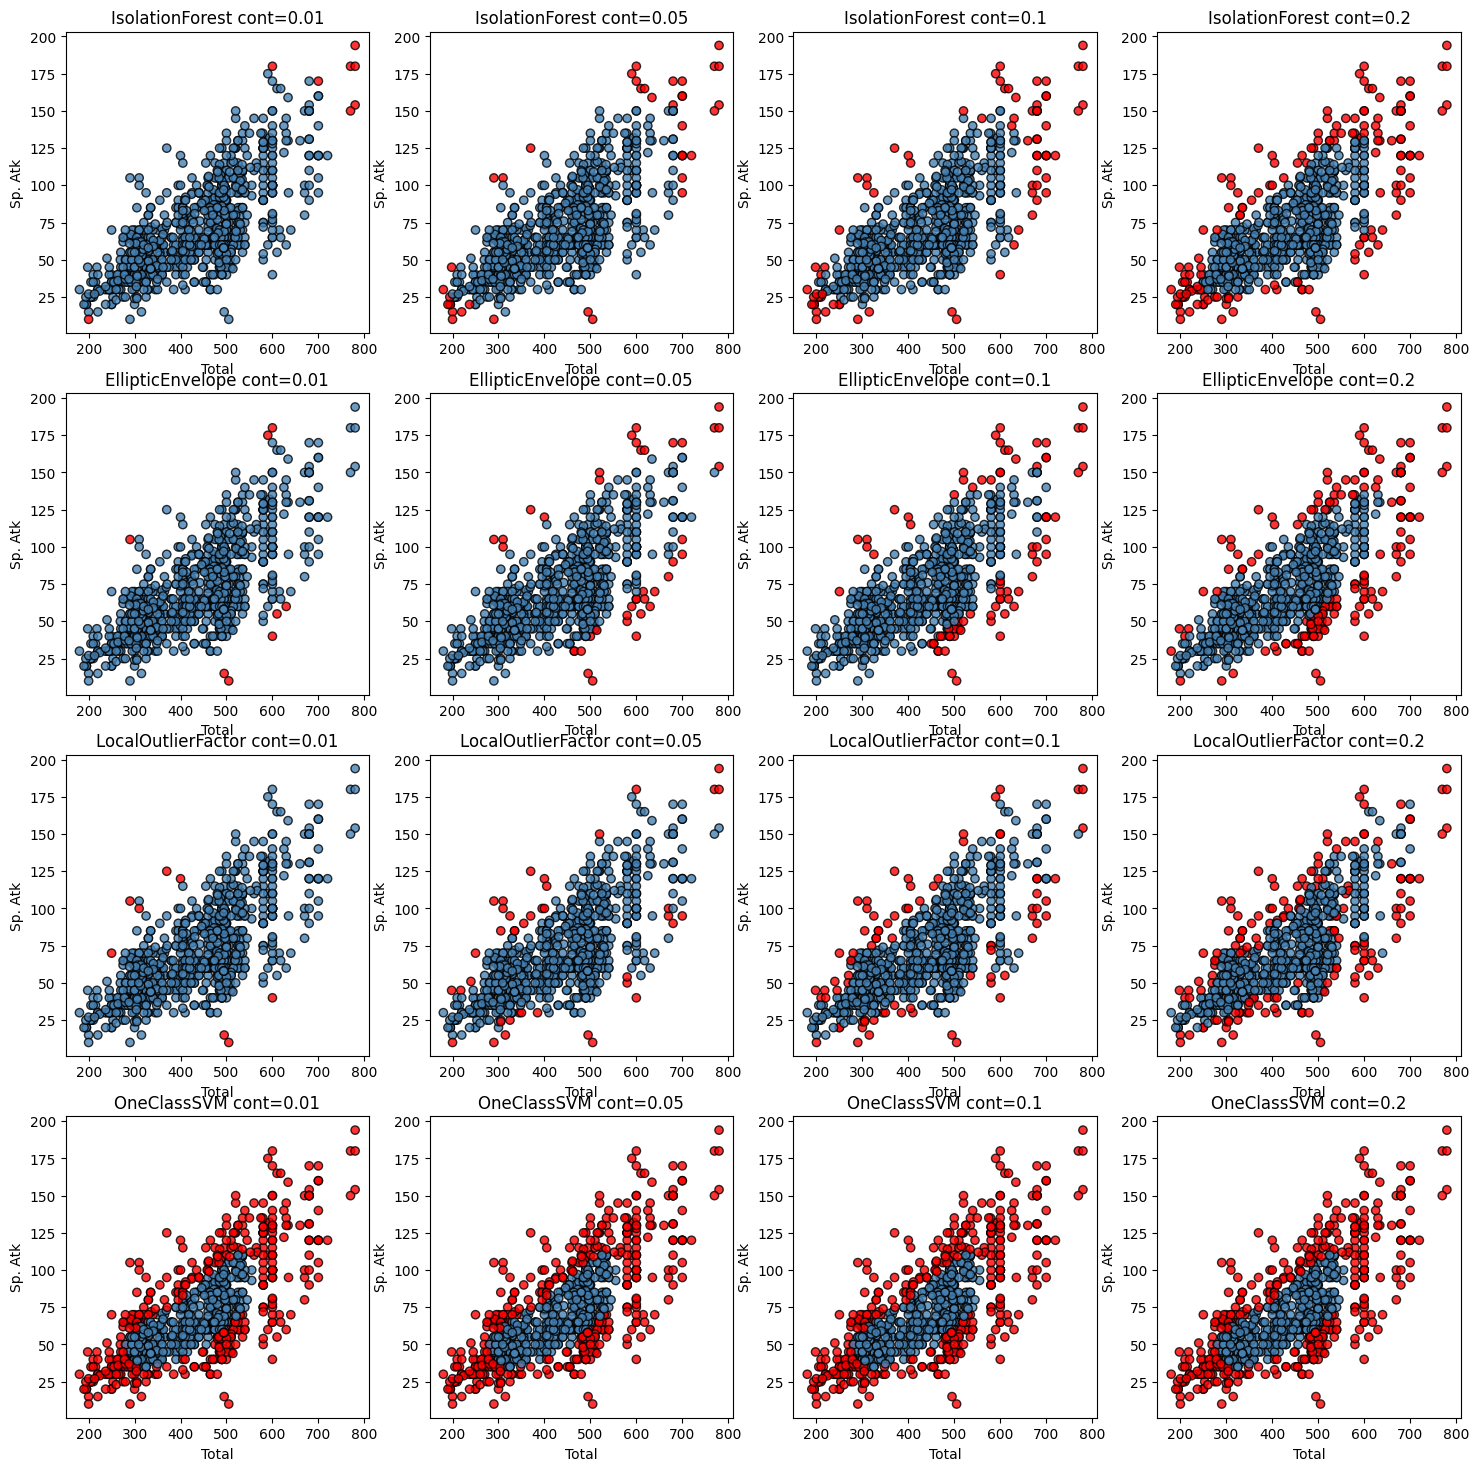

In [133]:
contaminations = [0.01, 0.05, 0.1, 0.2]
models = [IsolationForest, EllipticEnvelope, LocalOutlierFactor, OneClassSVM]

fig, axes = plt.subplots(
    len(models),
    len(contaminations),
    figsize=(18, 18)
)

global_labels = {}

for k, model_class in enumerate(models):
    model_name = model_class().__class__.__name__
    global_labels[model_name] = []

    for i, contamination in enumerate(contaminations):
        ax = axes[k, i]
        model = create_model(model_class, contamination=contamination)
        labels = gen_labels(model)
        plot_outliers(ax, labels, f"{model_name} cont={contamination}")

        negative_labels = np.where(labels == -1)[0]
        global_labels[model_name].append(len(negative_labels))

#### Contamination vs # of Outliers

`contamination` is the percentage of the dataset that we consider as "outliers". As a result, the number of outliers for each outlier detection model is almost identical to the `contamination` parameter. 

`OneClassSVM` does not have `contamination` attribute, so the result is the same for any contamination value. Its behaviour is changed by other hyperparameter, such as `gamma` or `degree` for polynomial SVM.

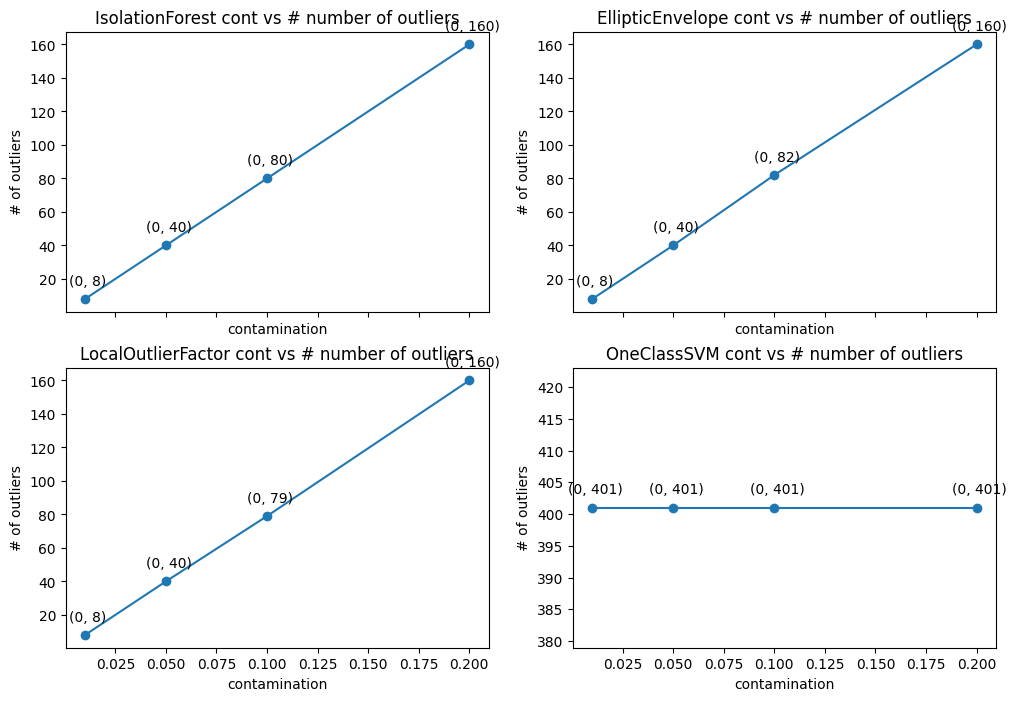

In [154]:
fig, axes = plt.subplots(
    len(models) // 2,
    2,
    figsize=(12, 8),
    sharex=True
)

for i, label_key in enumerate(global_labels.keys()):
    ax = axes[i // 2, i % 2]
    
    ax.set_title(f"{label_key} cont vs # number of outliers")
    ax.scatter(contaminations, global_labels[label_key])
    ax.set_xlabel('contamination')
    ax.set_ylabel('# of outliers')
    ax.plot(contaminations, global_labels[label_key])

    for x,y in zip(contaminations, global_labels[label_key]):
        label = "({:.0f}, {:.0f})".format(x, y)

        ax.annotate(label, # this is the text
                    (x,y), # these are the coordinates to position the label
                    textcoords="offset points", # how to position the text
                    xytext=(2,10), # distance from text to points (x,y)
                    ha='center') # horizontal alignment can be left, right or center

### Training

#### Split Train/Test

I was getting some determinant issues when using EllipticEnvelope on the entire dataset. I assume there is some numerical instability (multiple solutions for coefficient matrix), so I figured that `Total` column is a sum of other columns. I decided to remove it from the dataset to get rid of the warning. That improved the test results for all predictor models.

In [193]:
X = clean_df.drop(columns=['Legendary', 'Total'])
y = clean_df['Legendary'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Percentage of legendary pokemon in the test set is quite low. If a model predicts 0 for any sample, it already has 0.9375 accuracy, which is why it is important to look at the F1 score.

In [236]:
y_test.value_counts() / len(y_test)

Legendary
0    0.9375
1    0.0625
Name: count, dtype: float64

#### Training Outlier Models and Predictors

In [243]:
def get_predictor_pipeline(predictor_class, outlier_model_class):
    outlier_pipeline = make_pipeline(StandardScaler(), outlier_model_class)
    labels = outlier_pipeline.fit_predict(X_train)
    keep_rows = (labels == 1)

    X_train_proc = X_train.loc[keep_rows]
    y_train_proc = y_train.loc[keep_rows]

    predictor_pipeline = make_pipeline(StandardScaler(), predictor_class())
    predictor_pipeline.fit(X_train_proc, y_train_proc)

    return predictor_pipeline, X_train_proc, y_train_proc

In [244]:
predictors = [LogisticRegression, KNeighborsClassifier]
outlier_models = [IsolationForest(random_state=42), EllipticEnvelope(random_state=42), LocalOutlierFactor(), OneClassSVM()]

results = {
    "train": {},
    "test": {}
}

for predictor_class in predictors:
    predictor_name = predictor_class.__name__
    results["train"][predictor_name] = {}
    results["test"][predictor_name] = {}

    for outlier_model_class in outlier_models:
        outlier_name = outlier_model_class.__class__.__name__
        predictor_pipeline, X_train_proc, y_train_proc = get_predictor_pipeline(predictor_class, outlier_model_class)

        y_train_pred = predictor_pipeline.predict(X_train_proc)
        y_test_pred = predictor_pipeline.predict(X_test)

        results["train"][predictor_name][outlier_name] = {
            "f1": f1_score(y_train_proc, y_train_pred, zero_division=0),
            "acc": accuracy_score(y_train_proc, y_train_pred)
        }
        results["test"][predictor_name][outlier_name] = {
            "f1": f1_score(y_test, y_test_pred, zero_division=0),
            "acc": accuracy_score(y_test, y_test_pred)
        }

#### Results Evaluation

We can see how big the difference is between accuracy and f1 score. This stems from the fact that our dataset is quite imbalanced in terms of legendary rows (which makes sense, since they are rare). A much larger proportion of non-legendary pokemons creates a bias both in the outlier detection and in the predicting model. Test F1 metrics matters the most here, and this should be the main metric to evaluate the performance of a model. From this, we can conclude that LogisticRegression with LocalOutlierFactor/OneClassSVM is the best combo, and KNeighborsClassifier with OneClassSVM is the worst one.

In [213]:
def heatmap_for(dict_key, metric, ax):

    metric_data = {
        predictor_name: {
            outlier_name: scores[metric]
            for outlier_name, scores in outlier_scores.items()
        }
        for predictor_name, outlier_scores in results[dict_key].items()
    }

    df = pd.DataFrame.from_dict(metric_data, orient="index")

    sns.heatmap(df, annot=True, fmt=".3f", vmin=0, vmax=1, ax=ax)
    ax.set_title(f"{dict_key} {metric.upper()}")
    ax.set_xlabel("Outlier method")
    ax.tick_params(axis="x", labelrotation=45)
    ax.tick_params(axis="y", labelrotation=45)

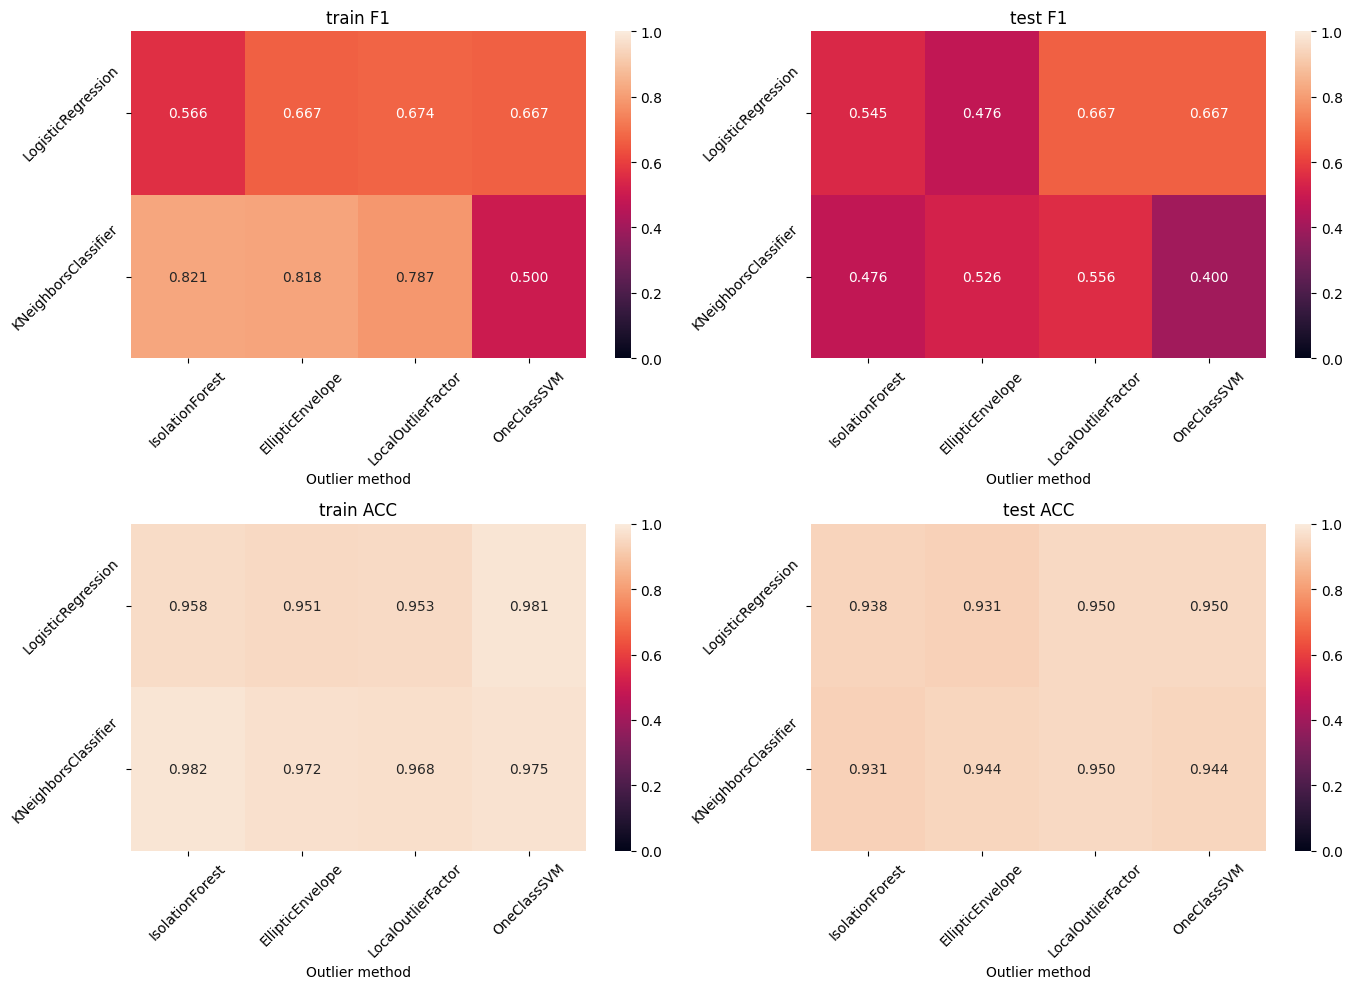

In [239]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

heatmap_for("train", "f1", axes[0, 0])
heatmap_for("test", "f1", axes[0, 1])
heatmap_for("train", "acc", axes[1, 0])
heatmap_for("test", "acc", axes[1, 1])

plt.tight_layout()

#### Comparing the Models

Let's see why and how the f1 score matters for the purpose of our pokemon classification. 

I will take LogisticRegression/LocalOutlierFactor as a good example and KNeighborsClassifier / OneClassSVM as a bad one.

In [258]:
def plot_roc_curve(y_true, y_proba):
    fpr, tpr, thresholds = roc_curve(y_true, y_proba)
    plt.plot(fpr, tpr)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')

#### LogisticRegression/LocalOutlierFactor

We can see that this combo only gave 2 false negatives, and we got 8 true positives.

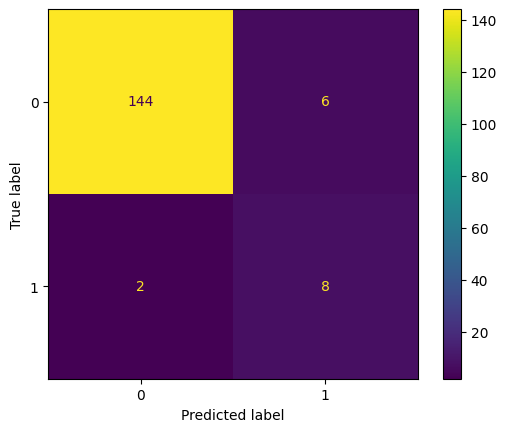

In [261]:
predictor_pipeline, X_train_proc, y_train_proc = get_predictor_pipeline(LogisticRegression, LocalOutlierFactor())
y_train_pred = predictor_pipeline.predict(X_train_proc)
y_test_pred = predictor_pipeline.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred)

High recall for positive class indicates that the model tries to choose legendary ones, even if it might be wrong (why is why precision for positive class is lower than for the example below).

In [254]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.99      0.96      0.97       150
           1       0.57      0.80      0.67        10

    accuracy                           0.95       160
   macro avg       0.78      0.88      0.82       160
weighted avg       0.96      0.95      0.95       160



Very high AUC score indicates that our model is very likely to correctly classify a true positive, rather than marking it a false positive, meaning it is very likely to correctly classify a pokemon as legendary rather than non-legendary. The rate of false-positives can be as low as 0.1, while achieving perfect true positive rate.

AUC Score: 0.9766666666666667


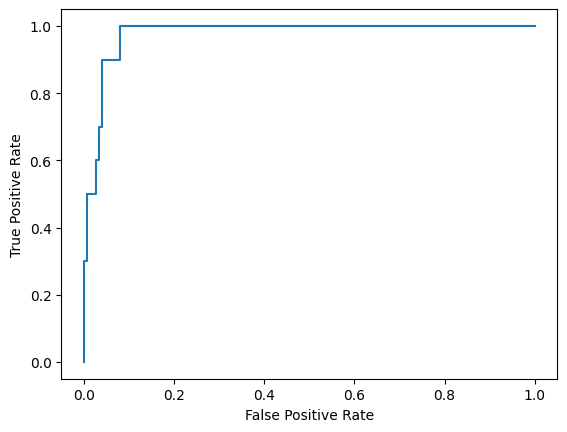

In [262]:
y_proba = predictor_pipeline.predict_proba(X_test)
y_proba_pos = y_proba[:, 1]
plot_roc_curve(y_test, y_proba_pos)
print(f"AUC Score: {roc_auc_score(y_test, y_proba_pos)}")

#### KNeighborsClassifier/OneClassSVM

For this combo, the model returns 7 false negative and only 3 true positives, which is not a good result, even though the overall accuracy looks very high.

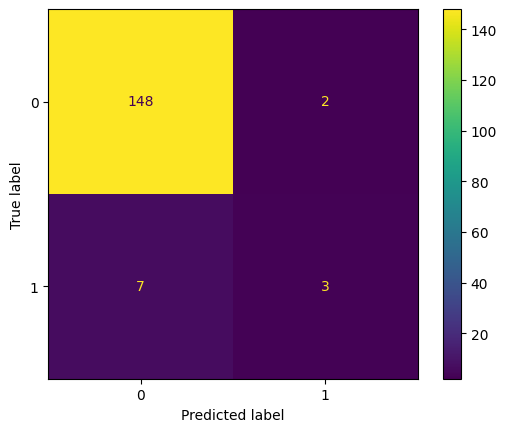

In [264]:
predictor_pipeline, X_train_proc, y_train_proc = get_predictor_pipeline(KNeighborsClassifier, OneClassSVM())
y_train_pred = predictor_pipeline.predict(X_train_proc)
y_test_pred = predictor_pipeline.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred)

Low recall for positive class indicates that the model does not really try to even predict the positive class. Positive class precision is better than for the previous combo, which might mean them model predicts positively for obvious legendary cards, but defaults for non-legendary ones.

In [256]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97       150
           1       0.60      0.30      0.40        10

    accuracy                           0.94       160
   macro avg       0.78      0.64      0.69       160
weighted avg       0.93      0.94      0.93       160



AUC score here is lower, and the ROC-AUC curve indicates that the model is very unlikely to correctly classify all true positives. The false positive rate grows as much as the true positive rate when the desires true positive rate is >0.9

AUC Score: 0.9133333333333333


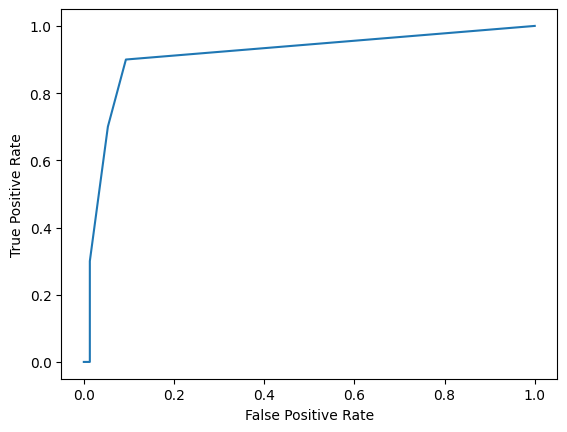

In [265]:
y_proba = predictor_pipeline.predict_proba(X_test)
y_proba_pos = y_proba[:, 1]
plot_roc_curve(y_test, y_proba_pos)
print(f"AUC Score: {roc_auc_score(y_test, y_proba_pos)}")